# 03 - Forecasting design and benchmark models

**Appliance energy forecasting**

**Input**

```text
data/processed/appliance_hourly.csv
```

**Outputs produced**

```text
outputs/forecasts/benchmark_forecasts_24h.csv
outputs/forecasts/benchmark_forecasts_rolling.csv
outputs/forecasts/benchmark_forecasts_full_test.csv
outputs/metrics/benchmark_metrics_24h.csv
outputs/metrics/benchmark_metrics_rolling.csv
outputs/metrics/benchmark_metrics_full_test.csv
outputs/metrics/benchmark_mase_scale.csv
outputs/figures/03_*.png
```

## 1. Setup

In [1]:
# 1. Imports

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 130)

plt.rcParams["figure.figsize"] = (13, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
# 2. Configuration

def find_project_root(markers=("data/raw", "data/processed", "notebooks"), start=None):
    """
    Locate the project root by walking up from the working directory.

    The root is the first ancestor containing any of `markers`, so this works on
    a fresh setup (before data/processed exists) as well as later, and does not
    depend on the notebook folder having a particular name.
    """

    start = Path.cwd().resolve() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        if any((candidate / m).exists() for m in markers):
            return candidate

    raise FileNotFoundError(
        f"No project root found from {start} upwards.\n"
        f"Looked for: {markers}\n"
        "Expected layout:  <project>/notebooks/*.ipynb  and  <project>/data/raw/"
    )


PROJECT_ROOT = find_project_root()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

FORECAST_DIR = OUTPUT_DIR / "forecasts"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURE_DIR = OUTPUT_DIR / "figures"

for path in [FORECAST_DIR, METRICS_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 0
rng = np.random.default_rng(RANDOM_STATE)

TARGET = "Appliances"

DAILY_PERIOD = 24
WEEKLY_PERIOD = 168

HORIZON = 24              # 24-hour forecast horizon, as required by the brief
TEST_STEPS = 14 * 24      # final 14 days held out
N_WINDOWS = TEST_STEPS // HORIZON


def save_fig(fig, name, figure_dir=FIGURE_DIR):
    """Save a figure to outputs/figures and report the path."""

    path = figure_dir / name

    fig.savefig(path, dpi=200, bbox_inches="tight")

    print("Saved figure:", path)

    return path


print("Project root:", PROJECT_ROOT)

Project root: C:\Users\cjfin\Desktop\assignment 2


In [3]:
# 3. Load the processed hourly series

data = pd.read_csv(
    PROCESSED_DIR / "appliance_hourly.csv",
    index_col=0,
    parse_dates=True,
).asfreq("h")

y = data[TARGET]

train = y.iloc[:-TEST_STEPS]
test = y.iloc[-TEST_STEPS:]

print("Full series :", len(y), "hours")
print("Train       :", len(train), "hours |", train.index.min(), "to", train.index.max())
print("Test        :", len(test), "hours |", test.index.min(), "to", test.index.max())
print("Windows     :", N_WINDOWS, "non-overlapping 24-hour forecasts")

assert test.isna().sum() == 0
assert len(test) == TEST_STEPS

Full series : 3289 hours
Train       : 2953 hours | 2016-01-11 17:00:00 to 2016-05-13 17:00:00
Test        : 336 hours | 2016-05-13 18:00:00 to 2016-05-27 17:00:00
Windows     : 14 non-overlapping 24-hour forecasts


## 2. Evaluation metrics

In [4]:
# 4. Metric functions

def mase_scale(y_train, seasonality=DAILY_PERIOD):
    """
    Scaling constant for MASE.

    This is the mean absolute error of an in-sample daily seasonal naive
    forecast on the training data. It is computed once and reused for every
    model and every window so that MASE values remain comparable.
    """

    y_train = pd.Series(y_train).astype(float)

    errors = np.abs(
        y_train.iloc[seasonality:].values
        - y_train.iloc[:-seasonality].values
    )

    return float(errors.mean())


def evaluate_forecast(name, y_true, y_pred, scale):
    """Compute MAE, RMSE, MASE and Bias for one forecast."""

    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).reindex(y_true.index).astype(float)

    valid = y_true.notna() & y_pred.notna()

    y_true = y_true[valid]
    y_pred = y_pred[valid]

    errors = y_pred - y_true

    return {
        "model": name,
        "n": len(y_true),
        "MAE": float(np.mean(np.abs(errors))),
        "RMSE": float(np.sqrt(np.mean(errors ** 2))),
        "MASE": float(np.mean(np.abs(errors)) / scale),
        "Bias": float(np.mean(errors)),
    }


def evaluate_all(forecast_df, y_true, scale):
    """Evaluate every column of a forecast table against the actuals."""

    rows = [
        evaluate_forecast(col, y_true, forecast_df[col], scale)
        for col in forecast_df.columns
        if col != "actual"
    ]

    return (
        pd.DataFrame(rows)
        .sort_values("MASE")
        .reset_index(drop=True)
    )


SCALE = mase_scale(train, seasonality=DAILY_PERIOD)

print("MASE scale (in-sample seasonal naive MAE on training data):", round(SCALE, 3), "Wh")

pd.Series({"mase_scale": SCALE, "seasonality": DAILY_PERIOD}).to_frame("value").to_csv(
    METRICS_DIR / "benchmark_mase_scale.csv"
)

MASE scale (in-sample seasonal naive MAE on training data): 53.359 Wh


In [5]:
# 5. Sanity checks on the metric functions

# A perfect forecast must give zero for every metric.
perfect = evaluate_forecast("perfect", test, test, SCALE)

assert np.isclose(perfect["MAE"], 0.0)
assert np.isclose(perfect["RMSE"], 0.0)
assert np.isclose(perfect["MASE"], 0.0)
assert np.isclose(perfect["Bias"], 0.0)

# A forecast that is uniformly 10 Wh too high must have Bias = +10 and MAE = 10.
offset = evaluate_forecast("offset", test, test + 10, SCALE)

assert np.isclose(offset["Bias"], 10.0)
assert np.isclose(offset["MAE"], 10.0)

print("Metric sanity checks passed.")
print("These assertions are the basis of tests/test_evaluation.py.")

Metric sanity checks passed.
These assertions are the basis of tests/test_evaluation.py.


## 3. Benchmark forecast functions

Five benchmarks are used;

| Benchmark | Rule | What it assumes |
|---|---|---|
| `mean` | Forecast the training mean for every hour | No structure at all |
| `naive` | Carry the last observation forward | The series is a random walk |
| `seasonal_naive_daily` | Same hour yesterday (lag 24) | The daily cycle repeats exactly |
| `seasonal_naive_weekly` | Same hour last week (lag 168) | The weekly cycle repeats exactly |
| `drift` | Last value plus the average historical slope | A linear trend continues |

In [6]:
# 6. Benchmark forecasts

def mean_forecast(y_train, horizon, index):
    """Forecast the historical mean at every step."""

    return pd.Series(float(y_train.mean()), index=index, name="mean")


def naive_forecast(y_train, horizon, index):
    """Carry the last observed value forward."""

    return pd.Series(float(y_train.iloc[-1]), index=index, name="naive")


def seasonal_naive_forecast(y_train, horizon, index, seasonality):
    """
    Seasonal naive forecast.

    Each step repeats the observation from one seasonal period earlier. Where the
    horizon exceeds the seasonal period, the recursion reuses forecasts already
    produced, which reproduces the last observed cycle repeatedly.
    """

    history = list(y_train.values)

    values = []

    for _ in range(horizon):
        values.append(history[-seasonality])
        history.append(values[-1])

    return pd.Series(values, index=index)


def drift_forecast(y_train, horizon, index):
    """
    Random walk with drift.

    The slope is the average change per step over the whole training history,
    which equals (last - first) / (n - 1).
    """

    slope = (y_train.iloc[-1] - y_train.iloc[0]) / (len(y_train) - 1)

    values = [
        y_train.iloc[-1] + slope * step
        for step in range(1, horizon + 1)
    ]

    return pd.Series(values, index=index, name="drift")

In [7]:
# 7. Assemble all benchmarks for one forecast origin

def make_benchmark_forecasts(y_train, horizon, index):
    """Produce every benchmark forecast for a single origin as one table."""

    forecasts = {
        "mean": mean_forecast(y_train, horizon, index),
        "naive": naive_forecast(y_train, horizon, index),
        "seasonal_naive_daily": seasonal_naive_forecast(
            y_train, horizon, index, seasonality=DAILY_PERIOD
        ),
        "seasonal_naive_weekly": seasonal_naive_forecast(
            y_train, horizon, index, seasonality=WEEKLY_PERIOD
        ),
        "drift": drift_forecast(y_train, horizon, index),
    }

    return pd.DataFrame(forecasts, index=index)


BENCHMARK_NAMES = [
    "mean",
    "naive",
    "seasonal_naive_daily",
    "seasonal_naive_weekly",
    "drift",
]

In [8]:
# 8. Verify the benchmarks behave as defined

check_index = test.index[:HORIZON]

check = make_benchmark_forecasts(train, HORIZON, check_index)

# Seasonal naive must equal the same hour one day / one week before the origin.
assert np.allclose(
    check["seasonal_naive_daily"].values,
    train.iloc[-DAILY_PERIOD:].values,
), "Daily seasonal naive does not reproduce the previous day"

assert np.allclose(
    check["seasonal_naive_weekly"].values,
    train.iloc[-WEEKLY_PERIOD:-WEEKLY_PERIOD + HORIZON].values,
), "Weekly seasonal naive does not reproduce the same hours last week"

# Naive and mean must be flat; the forecast index must match the test dates.
assert check["naive"].nunique() == 1
assert check["mean"].nunique() == 1
assert check.index.equals(check_index)
assert len(check) == HORIZON

# No forecast may use an observation from its own target window.
assert train.index.max() < check_index.min()

print("Benchmark definition checks passed.")

check.round(1).head(8)

Benchmark definition checks passed.


,mean,naive,seasonal_naive_daily,seasonal_naive_weekly,drift
date,,,,,
2016-05-13 18:00:00,97.4,231.7,105.0,176.7,231.7
2016-05-13 19:00:00,97.4,231.7,123.3,126.7,231.8
2016-05-13 20:00:00,97.4,231.7,100.0,116.7,231.8
2016-05-13 21:00:00,97.4,231.7,71.7,71.7,231.9
2016-05-13 22:00:00,97.4,231.7,60.0,53.3,232.0
2016-05-13 23:00:00,97.4,231.7,56.7,58.3,232.0
2016-05-14 00:00:00,97.4,231.7,55.0,51.7,232.1
2016-05-14 01:00:00,97.4,231.7,53.3,56.7,232.1


## 4. Protocol 1 - a single 24-hour forecast

The first forecast origin is the last training observation, 2016-05-13 17:00, and the
target window is the following 24 hours.

In [9]:
# 9. One 24-hour forecast from the start of the test period

first_window = test.index[:HORIZON]

fc_24h = make_benchmark_forecasts(train, HORIZON, first_window)
fc_24h.insert(0, "actual", test.loc[first_window])

metrics_24h = evaluate_all(fc_24h, test.loc[first_window], SCALE)

print("Forecast origin:", train.index.max())
print("Target window  :", first_window.min(), "to", first_window.max())
print()

metrics_24h.round(3)

Forecast origin: 2016-05-13 17:00:00
Target window  : 2016-05-13 18:00:00 to 2016-05-14 17:00:00



,model,n,MAE,RMSE,MASE,Bias
0,seasonal_naive_weekly,24,32.222,55.015,0.604,-18.611
1,mean,24,46.955,70.186,0.880,-15.887
2,seasonal_naive_daily,24,82.847,122.582,1.553,41.181
3,naive,24,128.958,136.722,2.417,118.403
4,drift,24,129.582,137.369,2.428,119.151


Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\03_single_24h_forecast.png


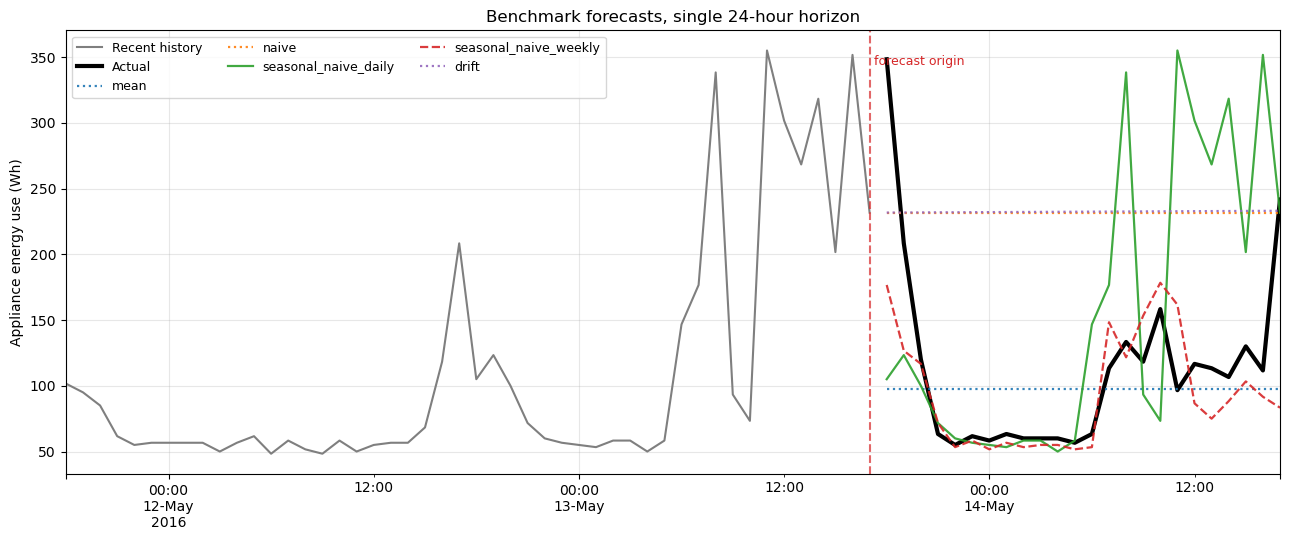

In [10]:
# 10. Plot the single 24-hour forecast

fig, ax = plt.subplots(figsize=(13, 5.5))

train.tail(48).plot(ax=ax, color="tab:grey", linewidth=1.5, label="Recent history")

fc_24h["actual"].plot(ax=ax, color="black", linewidth=3, label="Actual")

styles = {
    "mean": ":",
    "naive": ":",
    "drift": ":",
    "seasonal_naive_daily": "-",
    "seasonal_naive_weekly": "--",
}

for name in BENCHMARK_NAMES:
    fc_24h[name].plot(ax=ax, linewidth=1.6, alpha=0.9,
                      linestyle=styles[name], label=name)

ax.axvline(train.index.max(), color="tab:red", linestyle="--", alpha=0.7)
ax.text(train.index.max(), ax.get_ylim()[1] * 0.95, " forecast origin",
        color="tab:red", fontsize=9, va="top")

ax.set_title("Benchmark forecasts, single 24-hour horizon")
ax.set_ylabel("Appliance energy use (Wh)")
ax.set_xlabel("")
ax.legend(ncol=3, fontsize=9)

fig.tight_layout()
save_fig(fig, "03_single_24h_forecast.png")

plt.show()

A single day is a small sample and the ranking from it should not be trusted on its own -
which is the reason for the rolling-origin evaluation that follows.

## 5. Protocol 2 - rolling-origin evaluation 

In [11]:
# 11. Rolling-origin evaluation


def rolling_origin_benchmarks(y, test_index, horizon=HORIZON, forecast_fn=make_benchmark_forecasts):
    """
    Roll a forecast origin through the test period one horizon at a time.

    At each origin the history is every observation strictly before the window.
    Returns a long table with one row per (window, step) and one column per model.
    """

    split = y.index.get_loc(test_index[0])

    frames = []

    n_windows = len(test_index) // horizon

    for window in range(n_windows):
        start = split + window * horizon

        history = y.iloc[:start]
        window_index = y.index[start:start + horizon]

        # Guard against leakage: history must end before the window begins.
        assert history.index.max() < window_index.min()

        forecast = forecast_fn(history, horizon, window_index)

        forecast.insert(0, "actual", y.loc[window_index])
        forecast.insert(0, "step", np.arange(1, horizon + 1))
        forecast.insert(0, "origin", history.index.max())
        forecast.insert(0, "window", window + 1)

        frames.append(forecast)

    return pd.concat(frames)


rolling = rolling_origin_benchmarks(y, test.index)

print("Rolling forecast table:", rolling.shape)
print("Windows:", rolling["window"].nunique(), "| Steps per window:", rolling["step"].max())
print("Origins:", rolling["origin"].min(), "to", rolling["origin"].max())

rolling.head(3).round(1)

Rolling forecast table: (336, 9)
Windows: 14 | Steps per window: 24
Origins: 2016-05-13 17:00:00 to 2016-05-26 17:00:00


,window,origin,step,actual,mean,naive,seasonal_naive_daily,seasonal_naive_weekly,drift
date,,,,,,,,,
2016-05-13 18:00:00,1,2016-05-13 17:00:00,1,348.3,97.4,231.7,105.0,176.7,231.7
2016-05-13 19:00:00,1,2016-05-13 17:00:00,2,208.3,97.4,231.7,123.3,126.7,231.8
2016-05-13 20:00:00,1,2016-05-13 17:00:00,3,120.0,97.4,231.7,100.0,116.7,231.8


In [12]:
# 12. Headline metrics, pooled over all 14 windows

metrics_rolling = evaluate_all(
    rolling[BENCHMARK_NAMES],
    rolling["actual"],
    SCALE,
)

best_benchmark = metrics_rolling.iloc[0]["model"]

print("Rolling-origin benchmark performance (14 windows x 24 hours):\n")
print(metrics_rolling.round(3).to_string(index=False))

print("\nStrongest benchmark:", best_benchmark)

Rolling-origin benchmark performance (14 windows x 24 hours):

                model   n     MAE    RMSE  MASE    Bias
seasonal_naive_weekly 336  42.922  79.668 0.804 -12.624
 seasonal_naive_daily 336  48.393  85.790 0.907   1.667
                 mean 336  50.010  73.986 0.937  -3.061
                naive 336 143.383 170.623 2.687 114.673
                drift 336 143.942 171.260 2.698 115.314

Strongest benchmark: seasonal_naive_weekly


In [13]:
# 13. Is the ranking stable, or driven by one bad day?

per_window = (
    rolling
    .groupby("window")
    .apply(lambda g: pd.Series({
        name: np.mean(np.abs(g[name] - g["actual"]))
        for name in BENCHMARK_NAMES
    }))
)

per_window.insert(0, "date", rolling.groupby("window")["origin"].first().dt.date.values)

print("MAE by window (Wh):\n")
print(per_window.round(1).to_string())

wins = (
    per_window[BENCHMARK_NAMES]
    .idxmin(axis=1)
    .value_counts()
    .rename("windows_won")
)

print("\nNumber of windows in which each benchmark had the lowest MAE:")
print(wins.to_string())

MAE by window (Wh):

              date  mean  naive  seasonal_naive_daily  seasonal_naive_weekly  drift
window                                                                             
1       2016-05-13  47.0  129.0                  82.8                   32.2  129.6
2       2016-05-14  33.5  149.6                  28.0                   37.3  150.4
3       2016-05-15  48.5  129.0                  38.2                   37.2  129.5
4       2016-05-16  41.0  175.9                  51.6                    7.0  176.7
5       2016-05-17  31.1   80.6                  14.9                   13.8   81.0
6       2016-05-18  48.2   62.3                  20.2                   16.8   62.5
7       2016-05-19  33.0  138.1                  29.0                   88.1  138.7
8       2016-05-20  97.9   94.4                  94.4                   97.6   94.4
9       2016-05-21  48.5   48.7                  75.7                   37.2   48.6
10      2016-05-22  45.4  190.6                  51.0  

In [14]:
# 14. Bootstrap comparison against the strongest benchmark

def bootstrap_mae_difference(errors_a, errors_b, n_boot=2000, rng=rng):
    """
    Percentile bootstrap confidence interval for the difference in MAE.

    Resamples 24-hour blocks rather than individual hours, because forecast
    errors within a day are strongly correlated and hour-level resampling would
    understate the uncertainty.
    """

    a = np.abs(np.asarray(errors_a)).reshape(-1, HORIZON)
    b = np.abs(np.asarray(errors_b)).reshape(-1, HORIZON)

    observed = a.mean() - b.mean()

    n_blocks = a.shape[0]

    draws = np.empty(n_boot)

    for i in range(n_boot):
        idx = rng.integers(0, n_blocks, n_blocks)
        draws[i] = a[idx].mean() - b[idx].mean()

    lower, upper = np.percentile(draws, [2.5, 97.5])

    return observed, lower, upper


reference_errors = rolling[best_benchmark] - rolling["actual"]

comparison_rows = []

for name in BENCHMARK_NAMES:
    if name == best_benchmark:
        continue

    observed, lower, upper = bootstrap_mae_difference(
        rolling[name] - rolling["actual"],
        reference_errors,
    )

    comparison_rows.append({
        "model": name,
        "MAE_difference": observed,
        "ci_lower": lower,
        "ci_upper": upper,
        "clearly_worse": bool(lower > 0),
    })

comparison = pd.DataFrame(comparison_rows)

print(f"MAE difference against the strongest benchmark ({best_benchmark}).")
print("Positive means worse. 95% block-bootstrap interval.\n")
print(comparison.round(2).to_string(index=False))

MAE difference against the strongest benchmark (seasonal_naive_weekly).
Positive means worse. 95% block-bootstrap interval.

               model  MAE_difference  ci_lower  ci_upper  clearly_worse
                mean            7.09     -5.57     16.26          False
               naive          100.46     60.96    144.81           True
seasonal_naive_daily            5.47     -8.47     18.57          False
               drift          101.02     63.11    143.52           True


In [15]:
# 14b. Pairwise comparison of the three seasonal benchmarks

seasonal_models = [
    "seasonal_naive_weekly",
    "seasonal_naive_daily",
]

pairwise_rows = []

for i, model_a in enumerate(seasonal_models):
    for model_b in seasonal_models[i + 1:]:
        observed, lower, upper = bootstrap_mae_difference(
            rolling[model_a] - rolling["actual"],
            rolling[model_b] - rolling["actual"],
        )

        pairwise_rows.append({
            "comparison": f"{model_a} - {model_b}",
            "MAE_difference": observed,
            "ci_lower": lower,
            "ci_upper": upper,
            "distinguishable": bool(lower > 0 or upper < 0),
        })

print("Pairwise MAE differences among the seasonal benchmarks.")
print("Negative means the first model is better. 95% block-bootstrap interval.\n")
print(pd.DataFrame(pairwise_rows).round(2).to_string(index=False))

Pairwise MAE differences among the seasonal benchmarks.
Negative means the first model is better. 95% block-bootstrap interval.

                                  comparison  MAE_difference  ci_lower  ci_upper  distinguishable
seasonal_naive_weekly - seasonal_naive_daily           -5.47    -18.96      8.75            False


## 6. Where do the errors fall?

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\03_rolling_forecasts.png


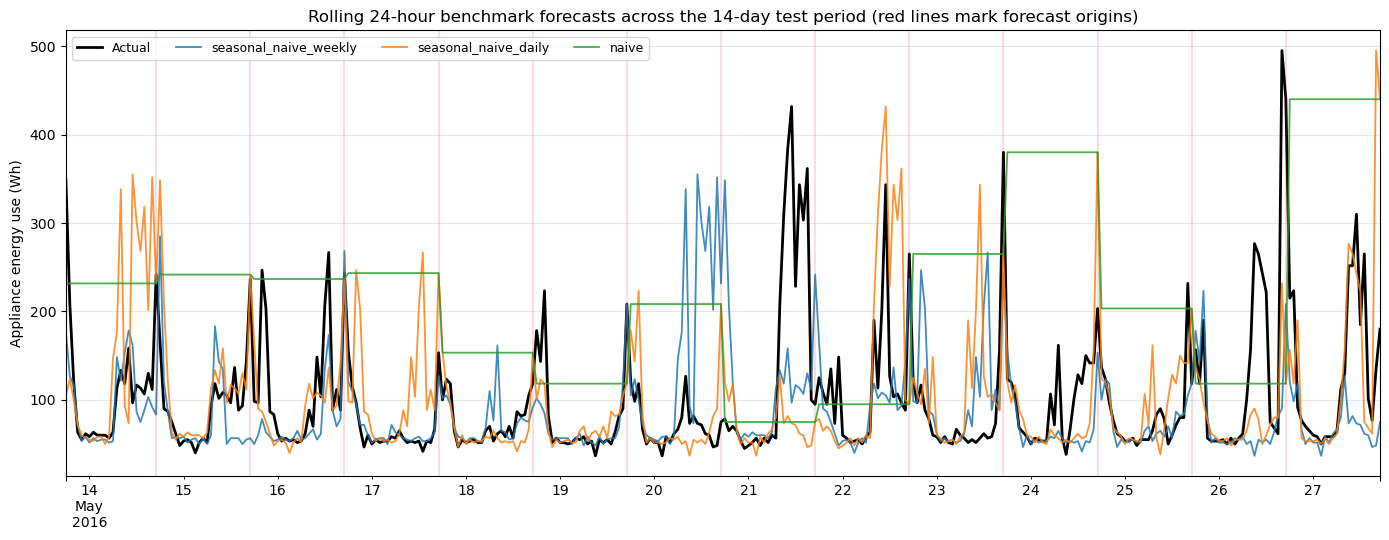

In [16]:
# 15. Stitched rolling forecasts across the full test period

stitched = rolling.set_index(rolling.index)

fig, ax = plt.subplots(figsize=(14, 5.5))

stitched["actual"].plot(ax=ax, color="black", linewidth=2, label="Actual")

for name in ["seasonal_naive_weekly", "seasonal_naive_daily", "naive"]:
    stitched[name].plot(ax=ax, linewidth=1.3, alpha=0.85, label=name)

for origin in rolling.groupby("window")["origin"].first():
    ax.axvline(origin, color="tab:red", alpha=0.15)

ax.set_title("Rolling 24-hour benchmark forecasts across the 14-day test period "
             "(red lines mark forecast origins)")
ax.set_ylabel("Appliance energy use (Wh)")
ax.set_xlabel("")
ax.legend(ncol=4, fontsize=9)

fig.tight_layout()
save_fig(fig, "03_rolling_forecasts.png")

plt.show()

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\03_error_by_step_and_hour.png


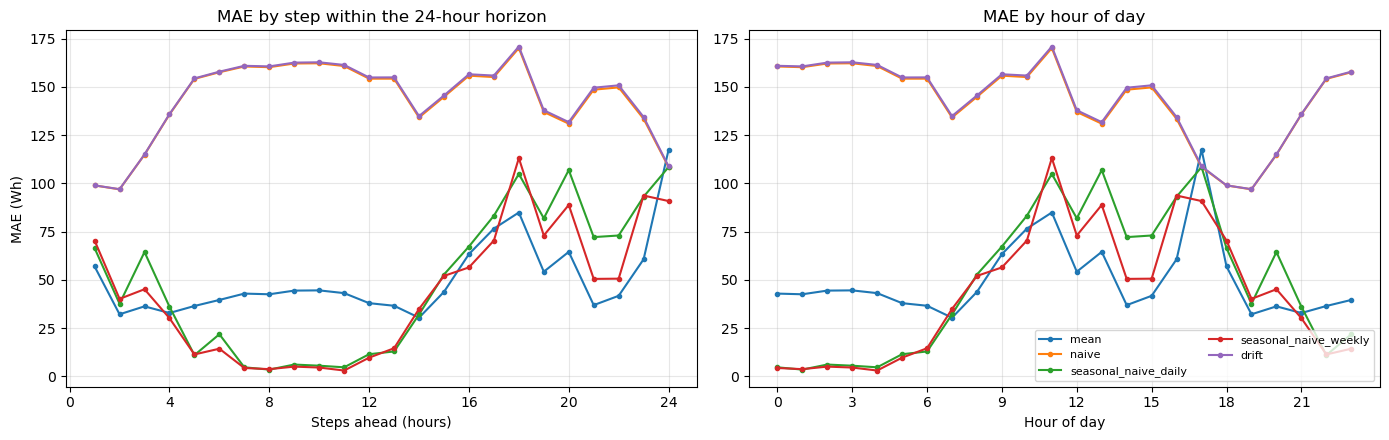

MAE by step, selected steps:
       mean  naive  seasonal_naive_daily  seasonal_naive_weekly  drift
step                                                                  
1      56.9   98.9                  66.4                   70.4   99.0
6      39.6  157.6                  21.8                   14.3  157.9
12     37.9  154.3                  11.4                    9.6  154.9
18     84.9  170.1                 104.9                  113.1  170.9
24    117.4  108.5                 108.5                   90.8  108.8


In [17]:
# 16. Error by step within the horizon, and by hour of day

by_step = (
    rolling
    .groupby("step")
    .apply(lambda g: pd.Series({
        name: np.mean(np.abs(g[name] - g["actual"]))
        for name in BENCHMARK_NAMES
    }))
)

rolling_hours = rolling.copy()
rolling_hours["hour"] = rolling_hours.index.hour

by_hour = (
    rolling_hours
    .groupby("hour")
    .apply(lambda g: pd.Series({
        name: np.mean(np.abs(g[name] - g["actual"]))
        for name in BENCHMARK_NAMES
    }))
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for name in BENCHMARK_NAMES:
    axes[0].plot(by_step.index, by_step[name], marker="o", markersize=3, label=name)
    axes[1].plot(by_hour.index, by_hour[name], marker="o", markersize=3, label=name)

axes[0].set_title("MAE by step within the 24-hour horizon")
axes[0].set_xlabel("Steps ahead (hours)")
axes[0].set_ylabel("MAE (Wh)")
axes[0].set_xticks(range(0, 25, 4))

axes[1].set_title("MAE by hour of day")
axes[1].set_xlabel("Hour of day")
axes[1].set_xticks(range(0, 24, 3))
axes[1].legend(ncol=2, fontsize=8)

fig.tight_layout()
save_fig(fig, "03_error_by_step_and_hour.png")

plt.show()

print("MAE by step, selected steps:")
print(by_step.loc[[1, 6, 12, 18, 24]].round(1).to_string())

Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\03_benchmark_residual_diagnostics.png


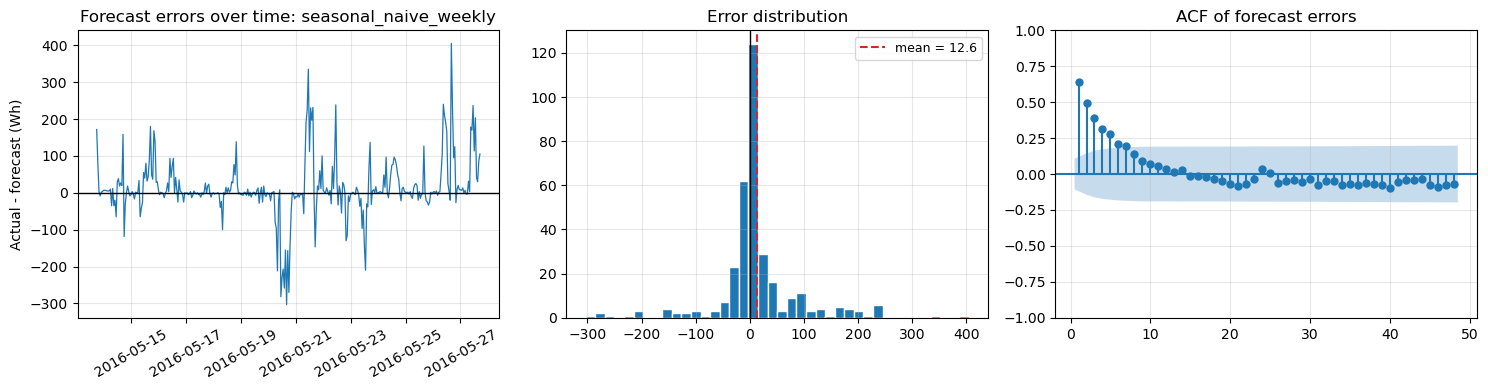

mean_error     12.62
std_error      78.78
skew            0.40
min          -303.33
max           405.00


In [18]:
# ------------------------------------------------------------
# 17. Residual diagnostics for the strongest benchmark
# ------------------------------------------------------------

best_errors = (rolling["actual"] - rolling[best_benchmark]).astype(float)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(best_errors.index, best_errors.values, linewidth=0.9, color="tab:blue")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title(f"Forecast errors over time: {best_benchmark}")
axes[0].set_ylabel("Actual - forecast (Wh)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].hist(best_errors.values, bins=40, color="tab:blue", edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].axvline(best_errors.mean(), color="tab:red", linestyle="--",
                label=f"mean = {best_errors.mean():.1f}")
axes[1].set_title("Error distribution")
axes[1].legend(fontsize=9)

plot_acf(best_errors.values, lags=48, ax=axes[2], zero=False)
axes[2].set_title("ACF of forecast errors")

fig.tight_layout()
save_fig(fig, "03_benchmark_residual_diagnostics.png")

plt.show()

print(pd.Series({
    "mean_error": best_errors.mean(),
    "std_error": best_errors.std(),
    "skew": best_errors.skew(),
    "min": best_errors.min(),
    "max": best_errors.max(),
}).round(2).to_string())

## 7. Protocol 3 - a single 336-step forecast

In [19]:
# 18. One forecast covering the entire test period

fc_full = make_benchmark_forecasts(train, TEST_STEPS, test.index)
fc_full.insert(0, "actual", test)

metrics_full = evaluate_all(fc_full[BENCHMARK_NAMES], test, SCALE)

print("Single 336-step forecast (14 days ahead from one origin):\n")
print(metrics_full.round(3).to_string(index=False))

Single 336-step forecast (14 days ahead from one origin):

                model   n     MAE    RMSE  MASE    Bias
seasonal_naive_weekly 336  42.391  78.528 0.794 -11.597
                 mean 336  50.047  73.956 0.938  -2.951
 seasonal_naive_daily 336  80.685 123.117 1.512  54.117
                naive 336 142.907 150.701 2.678 131.339
                drift 336 151.282 159.321 2.835 141.423


MASE under each evaluation protocol:

                       single_24h_MASE  rolling_24h_MASE  single_336h_MASE
model                                                                     
mean                             0.880             0.937             0.938
naive                            2.417             2.687             2.678
seasonal_naive_daily             1.553             0.907             1.512
seasonal_naive_weekly            0.604             0.804             0.794
drift                            2.428             2.698             2.835
Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\03_protocol_comparison.png


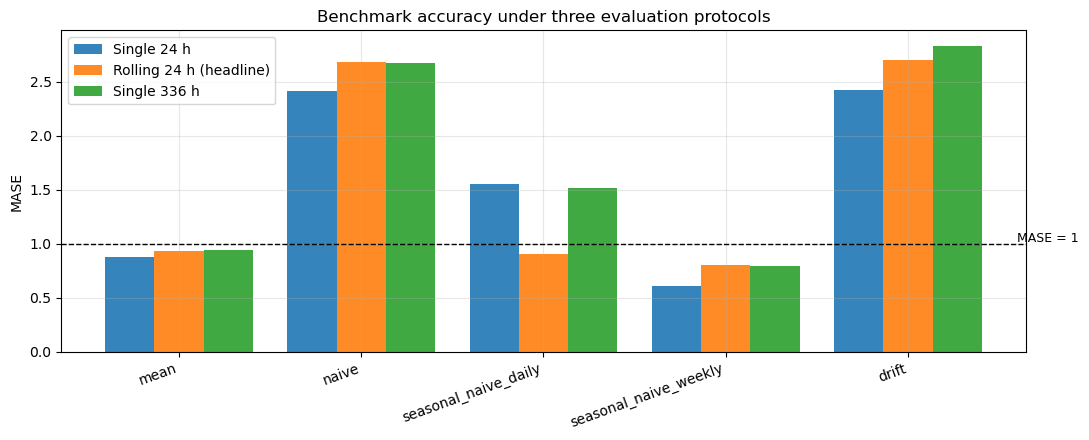

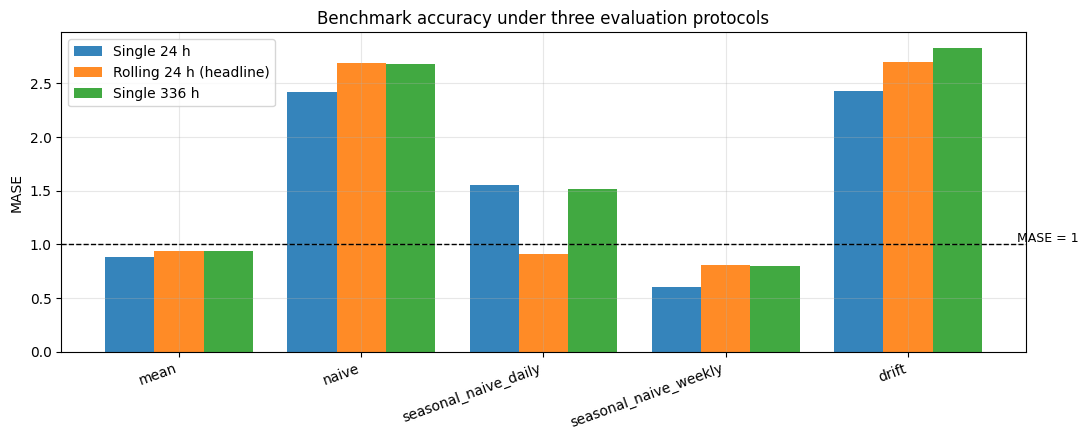

In [20]:
# 19. Compare the three protocols side by side

protocol_comparison = pd.DataFrame({
    "single_24h_MASE": metrics_24h.set_index("model")["MASE"],
    "rolling_24h_MASE": metrics_rolling.set_index("model")["MASE"],
    "single_336h_MASE": metrics_full.set_index("model")["MASE"],
}).loc[BENCHMARK_NAMES]

print("MASE under each evaluation protocol:\n")
print(protocol_comparison.round(3).to_string())

fig, ax = plt.subplots(figsize=(11, 4.5))

x = np.arange(len(BENCHMARK_NAMES))
width = 0.27

for offset, col, label in [
    (-width, "single_24h_MASE", "Single 24 h"),
    (0.0, "rolling_24h_MASE", "Rolling 24 h (headline)"),
    (width, "single_336h_MASE", "Single 336 h"),
]:
    ax.bar(x + offset, protocol_comparison[col].values, width, label=label, alpha=0.9)

ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax.text(len(x) - 0.4, 1.02, "MASE = 1", fontsize=9)

ax.set_xticks(x, BENCHMARK_NAMES, rotation=20, ha="right")
ax.set_ylabel("MASE")
ax.set_title("Benchmark accuracy under three evaluation protocols")
ax.legend()

fig.tight_layout()
save_fig(fig, "03_protocol_comparison.png")

plt.show()

## 10. Prediction intervals for the strongest benchmark

In [21]:
# 20. Empirical prediction intervals by hour of day

def empirical_intervals(y_train, forecast, seasonality=DAILY_PERIOD, levels=(0.80, 0.95)):
    """
    Prediction intervals from in-sample seasonal naive errors.

    Error quantiles are estimated per hour of day on the training data and added
    to the point forecast. No distributional assumption is made, and the interval
    width therefore varies across the day.
    """

    in_sample_errors = (y_train - y_train.shift(seasonality)).dropna()

    errors_by_hour = in_sample_errors.groupby(in_sample_errors.index.hour)

    out = pd.DataFrame(index=forecast.index)
    out["forecast"] = forecast.values

    for level in levels:
        alpha = (1 - level) / 2

        lower_q = errors_by_hour.quantile(alpha)
        upper_q = errors_by_hour.quantile(1 - alpha)

        hours = forecast.index.hour

        pct = int(level * 100)

        out[f"lower_{pct}"] = forecast.values + lower_q.reindex(hours).values
        out[f"upper_{pct}"] = forecast.values + upper_q.reindex(hours).values

    # Appliance energy use cannot be negative.
    for col in out.columns:
        if col.startswith("lower"):
            out[col] = out[col].clip(lower=0)

    return out


intervals = empirical_intervals(train, rolling[best_benchmark])
intervals["actual"] = rolling["actual"].values

coverage = pd.Series({
    "nominal_80_coverage": float(
        ((intervals["actual"] >= intervals["lower_80"]) &
         (intervals["actual"] <= intervals["upper_80"])).mean()
    ),
    "nominal_95_coverage": float(
        ((intervals["actual"] >= intervals["lower_95"]) &
         (intervals["actual"] <= intervals["upper_95"])).mean()
    ),
    "mean_80_width": float((intervals["upper_80"] - intervals["lower_80"]).mean()),
    "mean_95_width": float((intervals["upper_95"] - intervals["lower_95"]).mean()),
})

print("Empirical coverage on the test period:\n")
print(coverage.round(3).to_string())

Empirical coverage on the test period:

nominal_80_coverage      0.851
nominal_95_coverage      0.976
mean_80_width          154.356
mean_95_width          250.205


Saved figure: C:\Users\cjfin\Desktop\assignment 2\outputs\figures\03_benchmark_prediction_intervals.png


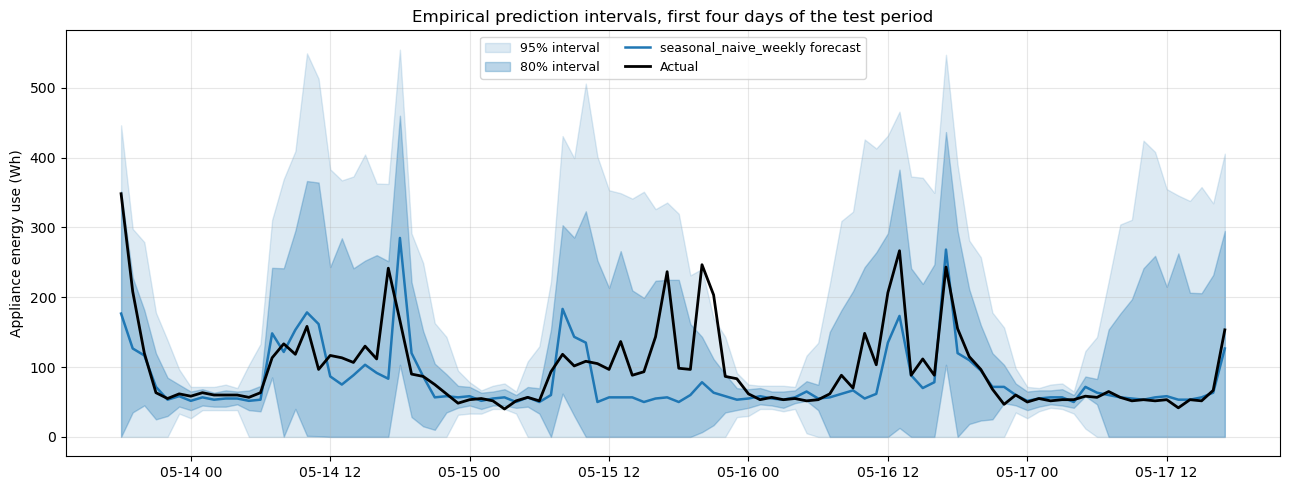

In [22]:
# 21. Plot the intervals over the first four test days

window_slice = intervals.iloc[:96]

fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(window_slice.index, window_slice["lower_95"], window_slice["upper_95"],
                color="tab:blue", alpha=0.15, label="95% interval")
ax.fill_between(window_slice.index, window_slice["lower_80"], window_slice["upper_80"],
                color="tab:blue", alpha=0.30, label="80% interval")

ax.plot(window_slice.index, window_slice["forecast"], color="tab:blue",
        linewidth=1.8, label=f"{best_benchmark} forecast")
ax.plot(window_slice.index, window_slice["actual"], color="black",
        linewidth=2, label="Actual")

ax.set_title("Empirical prediction intervals, first four days of the test period")
ax.set_ylabel("Appliance energy use (Wh)")
ax.legend(ncol=2, fontsize=9)

fig.tight_layout()
save_fig(fig, "03_benchmark_prediction_intervals.png")

plt.show()

## 10. Save outputs for the final comparison

In [23]:
# 22. Save forecasts and metrics

fc_24h.to_csv(FORECAST_DIR / "benchmark_forecasts_24h.csv")
rolling.to_csv(FORECAST_DIR / "benchmark_forecasts_rolling.csv")
fc_full.to_csv(FORECAST_DIR / "benchmark_forecasts_full_test.csv")

metrics_24h.to_csv(METRICS_DIR / "benchmark_metrics_24h.csv", index=False)
metrics_rolling.to_csv(METRICS_DIR / "benchmark_metrics_rolling.csv", index=False)
metrics_full.to_csv(METRICS_DIR / "benchmark_metrics_full_test.csv", index=False)

intervals.to_csv(FORECAST_DIR / "benchmark_prediction_intervals.csv")

for path in sorted(FORECAST_DIR.glob("benchmark_*")) + sorted(METRICS_DIR.glob("benchmark_*")):
    print("Saved:", path.relative_to(PROJECT_ROOT))

Saved: outputs\forecasts\benchmark_forecasts_24h.csv
Saved: outputs\forecasts\benchmark_forecasts_full_test.csv
Saved: outputs\forecasts\benchmark_forecasts_rolling.csv
Saved: outputs\forecasts\benchmark_prediction_intervals.csv
Saved: outputs\metrics\benchmark_mase_scale.csv
Saved: outputs\metrics\benchmark_metrics_24h.csv
Saved: outputs\metrics\benchmark_metrics_full_test.csv
Saved: outputs\metrics\benchmark_metrics_rolling.csv


In [24]:
# 23. Final check on the saved rolling forecasts

reloaded = pd.read_csv(
    FORECAST_DIR / "benchmark_forecasts_rolling.csv",
    index_col=0,
    parse_dates=True,
)

assert len(reloaded) == TEST_STEPS, "Rolling table length does not match the test period"
assert reloaded["window"].nunique() == N_WINDOWS
assert reloaded[BENCHMARK_NAMES].isna().sum().sum() == 0, "Missing benchmark forecasts"
assert reloaded.index.equals(test.index), "Forecast index does not match the test index"

print("Saved outputs verified.")
print("Rows:", len(reloaded), "| Windows:", reloaded["window"].nunique())

Saved outputs verified.
Rows: 336 | Windows: 14
